In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
sales_df = pd.read_csv("sales_data.csv")
churn_df = pd.read_csv("customer_churn.csv")

print("Sales Data Preview:")
print(sales_df.head())

print("\nColumns in Sales Dataset:")
print(sales_df.columns)

# IMPORTANT: sales column in your dataset
sales_col = "Total_Sales"

Sales Data Preview:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

Columns in Sales Dataset:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')


In [5]:
print("\n===== DESCRIPTIVE STATISTICS =====")

print(sales_df.describe())
print("\nMean:\n", sales_df.mean(numeric_only=True))
print("\nMedian:\n", sales_df.median(numeric_only=True))
print("\nMode:\n", sales_df.mode().iloc[0])
print("\nStandard Deviation:\n", sales_df.std(numeric_only=True))


===== DESCRIPTIVE STATISTICS =====
         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000

Mean:
 Quantity            4.78
Price           25808.51
Total_Sales    123650.48
dtype: float64

Median:
 Quantity           5.0
Price          24192.0
Total_Sales    97955.5
dtype: float64

Mode:
 Date           2024-01-01
Product            Tablet
Quantity              4.0
Price                1308
Customer_ID       CUST001
Region              North
Total_Sales          6540
Name: 0, dtype: object

Standard Deviation:
 Quantity            2.588163
Price           13917.630242
Total_Sales    100161.085275
dtype: float64


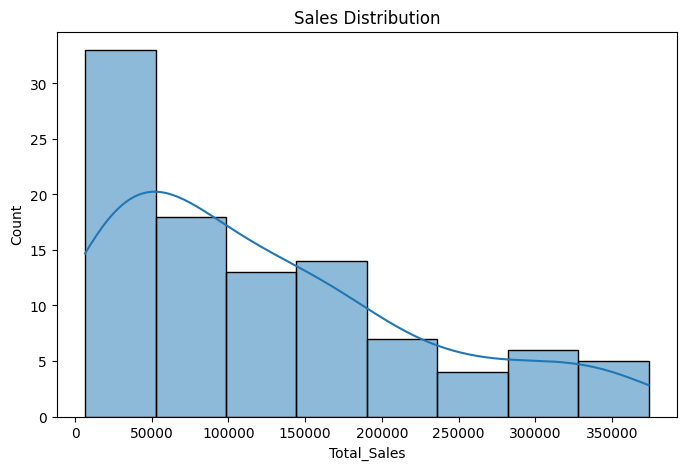


Shapiro Test p-value: 1.2590767205714734e-06


In [6]:
plt.figure(figsize=(8,5))
sns.histplot(sales_df[sales_col], kde=True)
plt.title("Sales Distribution")
plt.show()

stat, p_normal = stats.shapiro(sales_df[sales_col])
print("\nShapiro Test p-value:", p_normal)


===== CORRELATION ANALYSIS =====
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


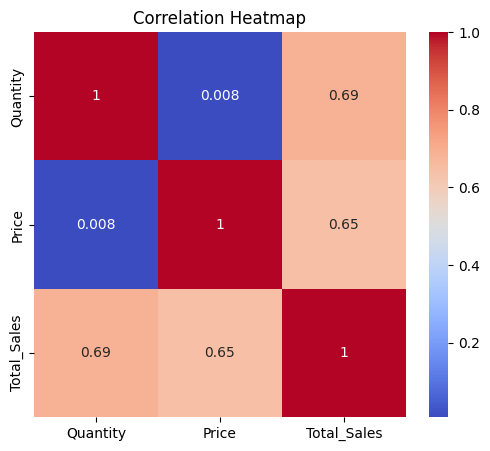

In [7]:
print("\n===== CORRELATION ANALYSIS =====")

corr = sales_df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [8]:
print("\n===== HYPOTHESIS TESTING =====")

regions = sales_df["Region"].unique()

# T-test (first two regions)
if len(regions) >= 2:
    group1 = sales_df[sales_df["Region"] == regions[0]][sales_col]
    group2 = sales_df[sales_df["Region"] == regions[1]][sales_col]

    t_stat, p_ttest = ttest_ind(group1, group2, equal_var=False)
    print(f"T-Test ({regions[0]} vs {regions[1]}) p-value:", p_ttest)
else:
    p_ttest = np.nan

# ANOVA
groups = [grp[sales_col].values for name, grp in sales_df.groupby("Region")]
f_stat, p_anova = f_oneway(*groups)
print("ANOVA p-value:", p_anova)

# Pearson correlation (if Marketing_Spend exists)
if "Marketing_Spend" in sales_df.columns:
    corr_coef, p_corr = stats.pearsonr(
        sales_df["Marketing_Spend"],
        sales_df[sales_col]
    )
    print("Pearson Correlation:", corr_coef)
    print("Correlation p-value:", p_corr)
else:
    corr_coef, p_corr = np.nan, np.nan
    print("Marketing_Spend column not found — skipping Pearson test.")

# =====================================================
# DAY 5 — CONFIDENCE INTERVAL
# =====================================================
print("\n===== CONFIDENCE INTERVAL =====")

mean_sales = sales_df[sales_col].mean()
std_sales = sales_df[sales_col].std()
n = len(sales_df)

confidence = 0.95
margin_error = stats.t.ppf((1 + confidence)/2, n-1) * (std_sales/np.sqrt(n))

lower = mean_sales - margin_error
upper = mean_sales + margin_error

print(f"Average Sales: {mean_sales:.2f} ± {margin_error:.2f}")
print(f"95% CI: [{lower:.2f}, {upper:.2f}]")


===== HYPOTHESIS TESTING =====
T-Test (East vs North) p-value: 0.7096254032191105
ANOVA p-value: 0.09723678084980039
Marketing_Spend column not found — skipping Pearson test.

===== CONFIDENCE INTERVAL =====
Average Sales: 123650.48 ± 19874.13
95% CI: [103776.35, 143524.61]


In [9]:
if "Marketing_Spend" in sales_df.columns:

    X = sales_df[["Marketing_Spend"]]
    y = sales_df[sales_col]

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)
    r2 = r2_score(y, pred)

    print("\n===== REGRESSION ANALYSIS =====")
    print("Coefficient:", model.coef_[0])
    print("Intercept:", model.intercept_)
    print("R² Score:", r2)

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=sales_df["Marketing_Spend"], y=sales_df[sales_col])
    plt.plot(sales_df["Marketing_Spend"], pred, color="red")
    plt.title("Regression: Marketing Spend vs Sales")
    plt.show()
else:
    r2 = np.nan

In [10]:
print("\n===== BUSINESS INSIGHTS =====")

if p_normal > 0.05:
    print("✔ Sales data follows normal distribution.")
else:
    print("⚠ Sales data is not normally distributed.")

if not np.isnan(p_corr):
    if p_corr < 0.05:
        print("✔ Marketing spend significantly affects sales.")
        print("➡ Recommendation: Increase marketing investment strategically.")
    else:
        print("✖ Marketing spend does not significantly impact sales.")

if p_anova < 0.05:
    print("✔ Sales vary significantly across regions.")
    print("➡ Recommendation: Study top-performing regions.")
else:
    print("✖ No significant difference between regions.")

if not np.isnan(r2):
    print(f"✔ Regression explains {r2:.2f} of sales variation.")
    print("➡ Use model for forecasting future sales.")

print(f"✔ Expected average sales range: {lower:.2f} – {upper:.2f}")


===== BUSINESS INSIGHTS =====
⚠ Sales data is not normally distributed.
✖ No significant difference between regions.
✔ Expected average sales range: 103776.35 – 143524.61


In [11]:
with open("hypothesis_tests_results.txt", "w") as f:
    f.write("STATISTICAL ANALYSIS REPORT\n")
    f.write(f"Average Sales: {mean_sales:.2f} ± {margin_error:.2f}\n")
    f.write(f"95% CI: [{lower:.2f}, {upper:.2f}]\n")
    f.write(f"ANOVA p-value: {p_anova}\n")
    f.write(f"Correlation: {corr_coef}\n")
    f.write(f"Regression R²: {r2}\n")

print("\n✅ Report saved successfully.")


✅ Report saved successfully.
